# 💾 **Downloading Data**

In [ ]:
# ⚙️ Run this cell only once to download and save the data.
# After this, you can skip it and directly load the CSV files.

import yfinance as yf

start_date = "2010-06-01"
end_date = "2020-06-30"

# Download data (each index in its own DataFrame)
sp500_data  = yf.download('^GSPC',  start=start_date, end=end_date)
dax_data    = yf.download('^GDAXI', start=start_date, end=end_date)
nikkei_data = yf.download('^N225',  start=start_date, end=end_date)

# Save the data as CSV files
sp500_data.to_csv("sp500_data.csv")
dax_data.to_csv("dax_data.csv")
nikkei_data.to_csv("nikkei_data.csv")


# ⚙️ Setup: Import Libraries, Load Data, and Define Functions

If you already have the historical data for the four indices saved as CSV files, you can **skip the previous cell** and start running from here.


In [4]:
# Importing required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import joblib # for saving the parameter of linear regression model
from statsmodels.tsa.stattools import adfuller, kpss

from fracdiff.sklearn import Fracdiff
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.notebook import tqdm
from tqdm import tqdm 

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)


In [7]:
# Function to read the CSV file and preprocess the data
def reading_file(file_name):
    """
    Read a CSV with a 2-row header (e.g., ('Price','Ticker')) and a date index,
    keep only the first header level ('Price'), and covert all values to numeric.
    """
    data = pd.read_csv(
        file_name,
        header=[0, 1],        # 2 header rows: ('Price', 'Ticker')
        index_col=0,          # first column is the date index
        parse_dates=True,
    )
    # Keep only the first level of the columns ('Price')
    data.columns = data.columns.get_level_values(0)
    # Ensure all entries are numeric (coerce non-numeric values to NaN)
    data = data.apply(pd.to_numeric, errors="coerce")
    return data

# Function to compute stationarity test statistics
def stationarity_values(series):
    """
    Compute ADF and KPSS test statistics .
    The series is cleaned with dropna() and cast to float before testing.

    """
    # ADF regression model being estimated:
    # Δy_t = α + β * y_{t-1} + γ₁ * Δy_{t-1} + ε_t	( since regression='c' and maxlag=1, autolag is the lag added )
    series = series.dropna().astype(float)
    a_stat, a_p, *_ = adfuller(series, maxlag=1, regression='c', autolag=None)
    k_stat, k_p, *_ = kpss(series, regression='c', nlags=1)
    return a_stat, a_p, k_stat, k_p

# Function to choose the right order of (fractional) differentiation for stationarity
def sweep_fractional_orders(series, d_list):
    """
    For a given series compute fractional differences of ['Close'] for each d in d_list and compute ADF stats.

    """
    window_size = 30
    rows = []
    for d in d_list:
        frac = Fracdiff(d, window=window_size, window_policy="fixed") 	# the window size is now default=10
        X = series[['Close']]          
        X_fd = frac.fit_transform(X).ravel()
        X_fd[:(window_size - 1)] = np.nan
        s_fd = pd.Series(X_fd)        								
        a_stat, a_p, _ , _ = stationarity_values(s_fd)
        rows.append({
            "d": d, "series": s_fd,
            "adf_stat": a_stat, "adf_p": a_p,
        })
    return rows


# Function to add fractional differencing column to the dataframe
def add_frac_diff_column(series, order_diff, cols, mode):
    """
    Add fractional differenced columns for each column in `cols` to `series`.
 
    """
    window_size = 30
    if mode == "fractional":
        fracdiff = Fracdiff(order_diff, window=window_size, window_policy="fixed") 		# the window size is now default=10
        for col in cols:											
            feature = series[[col]].astype(float).copy()			
            new_column = f"{col}_fd"
            series[new_column] = fracdiff.fit_transform(feature).ravel()
            series.iloc[:window_size-1, series.columns.get_loc(new_column)] = np.nan
    else:
        for col in cols:
            feature = series[col].copy()
            new_column = f"{col}_d"
            series[new_column] = feature.diff()
    return series


def plot_close_diff_frac_one(title, df, col_close="Close", col_frac="Close_fd"):
    """
    Plot the original, integer-differenced, and fractionally differenced series on the same figure using twin y-axes.
    Left axis → original series.
    Right axis → differenced series (integer + fractional).
    """
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Left axis: original prices 
    ax1.plot(df.index, df[col_close], lw=1.6, color="black", label="Original (Close)")
    ax1.set_ylabel("Original closing Price")
    ax1.set_xlabel("Date")

    # Right axis: integer and fractional differences 
    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col_frac], lw=1.0, color="tab:orange", label="Frac diff (d*)")
    ax2.set_ylabel("Closing Price after differentiation")


    # --- Legend and layout ---
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Function to create the dataset
def prepare_data(series, cols):
    """
    Prepare (fractional- or integer-differenced) OHLC features and next-day target.
    - Drops rows with NaNs in features or target.
    - Splits into train/val/test by index (70/15/15) and normalizes features and target.
    """
    dataset = series[cols].copy()
    # As a target variable we are using the log-return of the next day
    # Meaning we are considering log(P_t+1) - log(P_t) = log(P_t+1 / P_t) = log( 1 + R_t ) circa R_t (using taylor expansion for small R_t)
    target = series['Close_d'].shift(-1)

    # mask valid rows
    mask = dataset.notna().all(axis=1) & target.notna()
    X = dataset.loc[mask].astype(float).values
    y = target.loc[mask].astype(float).values.reshape(-1, 1)
    
    # Split the data into training, validation, and test sets (70/15/15)
    train_size = int(len(X) * 0.70)
    val_size = int(len(X) * 0.15)

    train_data, val_data = X[:train_size], X[train_size:train_size + val_size]
    target_train, target_val = y[:train_size], y[train_size:train_size + val_size]
    test_data, target_test = X[train_size + val_size:], y[train_size + val_size:]

    # Normalize data (since the target are just the next-day prices, we scale them too)
    scaler_data = StandardScaler()
    train_data = scaler_data.fit_transform(train_data)

    val_data, test_data = scaler_data.transform(val_data), scaler_data.transform(test_data)
    
    return train_data, val_data, test_data, target_train, target_val, target_test


# Function for training and evaluating models : it returns test metrics
def train_evaluate(weight_filename, train_data, val_data, test_data, target_train, target_val, target_test, n_features):
    """
    Build, train, and evaluate a shallow MLP, using one hidden layer and ReLU activations.
    Uses validation split and early stopping.

    Returns :  [loss, rmse, mae].
    """
    # Define the MLP model
    nhidden = 64
    model = nn.Sequential(nn.Linear(n_features, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, 1))

    # Transforming data into tensor
    train_data = torch.tensor(train_data, dtype=torch.float32)
    val_data = torch.tensor(val_data, dtype=torch.float32)
    test_data = torch.tensor(test_data, dtype=torch.float32)
    target_train = torch.tensor(target_train, dtype=torch.float32).view(-1, 1)
    target_val = torch.tensor(target_val, dtype=torch.float32).view(-1, 1)
    target_test = torch.tensor(target_test, dtype=torch.float32).view(-1, 1)

    # Dataset e DataLoader
    train_dataset = TensorDataset(train_data, target_train)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False) # Shuffle False because of time series data

    # Defining loss, optimizer and scheduler
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau( optimizer, mode='min', factor=0.5, patience=20, threshold=1e-4)

    # Training loop
    n_epochs = 250
    train_curve, val_curve = [], []
    training_loop = tqdm(range(n_epochs)) 
    for epoch in training_loop:
        # Training mode
        model.train() 
        running = 0.0 
        for batch_data, batch_targets in train_loader:
            # Reset computation graph
            optimizer.zero_grad()
            # Forward pass
            outputs = model(batch_data)
            # Compute training loss on batch
            loss = criterion(outputs, batch_targets)
            # Compute gradient 
            loss.backward()
            # Gradient step
            optimizer.step()
            # Loss per batch 
            running += loss.item()
        # Loss per epoch
        train_epoch = running / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_data)
            val_loss = criterion(val_outputs, target_val).item()
        # Scheduler step
        scheduler.step(val_loss)
        # Store train and validation loss 
        train_curve.append(train_epoch)
        val_curve.append(val_loss)

        # Print loss in the progression bar
        training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

    # Save the final model weights
    torch.save(model.state_dict(), weight_filename)
    # Plot losses
    plt.figure()
    plt.plot(train_curve, label='train')
    plt.plot(val_curve,   label='val')
    plt.yscale('log')  # optional
    plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
    plt.show()			

    # Metrics evaluation 
    model.load_state_dict(torch.load(weight_filename)) 
    model.eval()
    with torch.no_grad():
        predictions = model(test_data).numpy() 
        test_loss = mean_squared_error(target_test.numpy(), predictions)
        test_rmse = np.sqrt(test_loss)
        test_mae = mean_absolute_error(target_test.numpy(), predictions)

    
    return [test_loss, test_rmse, test_mae]

# Function for training and evaluating models : it returns test metrics
def train_evaluate_sw(weight_filename, train_data, val_data, test_data, target_train, target_val, target_test, n_features):
    """
    Build, train, and evaluate a shallow MLP, using one hidden layer and ReLU activations.
    Uses validation split and early stopping.

    Returns :  [loss, rmse, mae].
    """
    # Define the MLP model
    nhidden = 64
    model = nn.Sequential(nn.Linear(n_features, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, 1))

    # Transforming data into tensor
    train_data = torch.tensor(train_data, dtype=torch.float32)
    val_data = torch.tensor(val_data, dtype=torch.float32)
    test_data = torch.tensor(test_data, dtype=torch.float32)
    target_train = torch.tensor(target_train, dtype=torch.float32).view(-1, 1)
    target_val = torch.tensor(target_val, dtype=torch.float32).view(-1, 1)
    target_test = torch.tensor(target_test, dtype=torch.float32).view(-1, 1)

    # Dataset e DataLoader
    train_dataset = TensorDataset(train_data, target_train)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False) # Shuffle False because of time series data

    # Defining loss, optimizer and scheduler
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau( optimizer, mode='min', factor=0.5, patience=30, threshold=1e-4)

    # Training loop
    n_epochs = 250
    train_curve, val_curve = [], []
    training_loop = tqdm(range(n_epochs)) 
    for epoch in training_loop:
        # Training mode
        model.train() 
        running = 0.0 
        for batch_data, batch_targets in train_loader:
            # Reset computation graph
            optimizer.zero_grad()
            # Forward pass
            outputs = model(batch_data)
            # Compute training loss on batch
            loss = criterion(outputs, batch_targets)
            # Compute gradient 
            loss.backward()
            # Gradient step
            optimizer.step()
            # Loss per batch 
            running += loss.item()
        # Loss per epoch
        train_epoch = running / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_data)
            val_loss = criterion(val_outputs, target_val).item()
        # Scheduler step
        scheduler.step(val_loss)
        # Store train and validation loss 
        train_curve.append(train_epoch)
        val_curve.append(val_loss)

        # Print loss in the progression bar
        training_loop.set_postfix(train=train_epoch, val=val_loss, lr=optimizer.param_groups[0]['lr'])

    # Save the final model weights
    torch.save(model.state_dict(), weight_filename)
    # Plot losses
    plt.figure()
    plt.plot(train_curve, label='train')
    plt.plot(val_curve,   label='val')
    plt.yscale('log')  # optional
    plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
    plt.show()			

    # Metrics evaluation 
    model.load_state_dict(torch.load(weight_filename)) 
    model.eval()
    with torch.no_grad():
        predictions = model(test_data).numpy() 
        test_loss = mean_squared_error(target_test.numpy(), predictions)
        test_rmse = np.sqrt(test_loss)
        test_mae = mean_absolute_error(target_test.numpy(), predictions)

    
    return [test_loss, test_rmse, test_mae]

# This function prepares the dataset using a sliding window approach.
def prepare_data_sw(series, cols, window_size):
    """
    Prepare (fractional- or integer-differenced) OHLC features and next-day target using a sliding window approach:
    - The input dataset has dimensions (window_size x 4), where the window size determines the number of past time steps used.
    - Drops rows with NaNs in features or target.
    - Splits into train/val/test by index (70/15/15) and normalizes features and target.
    Note: The first `window_size` values cannot be used for training due to the sliding window mechanism, same for test set,
    reducing the usable dataset size by `window_size`.

    """
    dataset = series[cols].copy()
    # As a target variable we are using the log-return of the next day
    # Meaning we are considering log(P_t+1) - log(P_t) = log(P_t+1 / P_t) = log( 1 + R_t ) circa R_t (using taylor expansion for small R_t)
    target = series['Close_d'].shift(-1) 
    # mask valid rows
    mask = dataset.notna().all(axis=1) & target.notna()
    X = dataset.loc[mask].astype(float).values
    y = target.loc[mask].astype(float).values.reshape(-1, 1)
    
    # Create the new datasets using the sliding window approach: instead of having that n_samples x 4, we have (n_samples - window_size) x (window_size * 4)
    X_sw = np.array([ X[i:i + window_size].flatten()  for i in range(len(X) - window_size + 1) ])
    y_sw = y[window_size-1:]
    
    # Split the data into training, validation, and test sets (70/15/15)
    train_size = int(len(X_sw) * 0.70)
    val_size = int(len(X_sw) * 0.15)

    train_data, val_data = X_sw[:train_size], X_sw[train_size:train_size + val_size]
    target_train, target_val = y_sw[:train_size], y_sw[train_size:train_size + val_size]
    test_data, target_test = X_sw[train_size + val_size:], y_sw[train_size + val_size:]

    # Normalize data
    scaler_data = StandardScaler()
    train_data = scaler_data.fit_transform(train_data)
    val_data, test_data = scaler_data.transform(val_data), scaler_data.transform(test_data)
    
    return train_data, val_data, test_data, target_train, target_val, target_test

def lin_reg(weight_filename, train_set, test_set, target_train, target_test):
    model = LinearRegression()
    model.fit(train_set, target_train)
    # Save the linear regression model
    joblib.dump(model, weight_filename)
    # Make predictions
    pred = model.predict(test_set)
    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(target_test, pred))
    mae = mean_absolute_error(target_test, pred)

    return [rmse, mae]
    
def compare_models(results, metric, mode):
    """
    Compare integer- vs fractional-differenced models across indices.
    DataFrame with per-index comparison and a dict with average improvements:
    - abs_improvement = integer - fractional  (positive => fractional better)
    - pct_improvement = 100 * (integer - fractional) / integer
    """
    if mode == 'loss':
        idx = {"loss":0, "rmse":1, "mae":2}[metric]
    else:
        idx = {"rmse":0, "mae":1}[metric]
    rows = []
    for name in ["sp500", "dax", "nikkei"]:
        base = results[f"{name}_d"][idx]     # integer-diff (baseline)
        cand = results[f"{name}_fd"][idx]    # fractional-diff (candidate)
        rows.append({
            "index": name.upper(),
            f"{metric}_integer": base,
            f"{metric}_fractional": cand,
            "abs_improvement": base - cand,                 # + => fractional better
            "pct_improvement": 100.0 * (base - cand) / base,
        })
    df = pd.DataFrame(rows)
    # Optional: add an average row for improvements
    avg = {
        "index": "AVERAGE",
        "abs_improvement": df["abs_improvement"].mean(),
        "pct_improvement": df["pct_improvement"].mean(),
    }
    return df, avg


def trading_signal_strategy(series, test_set, weight_file, mode, n_features, model):
    """
    Simulates a trading strategy based on model predictions.

    """
    # Ensure inputs are numpy arrays
    actual_price = series['Close'].iloc[-(len(test_set))-1:].values.astype(float)
    predictions = np.empty(len(test_set))
    nhidden = 64
    if model == "neural_network":
        if mode == "sliding_window":
            nn_model = nn.Sequential(nn.Linear(n_features, nhidden),
                        nn.ReLU(),
                        nn.Linear(nhidden, 1))
            nn_model.load_state_dict(torch.load(weight_file))
            nn_model.eval()
            with torch.no_grad():
                test_set = torch.tensor(test_set, dtype=torch.float32)
                predictions = nn_model(test_set).numpy()
        else:
            nn_model = nn.Sequential(nn.Linear(n_features, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, nhidden),
                            nn.ReLU(),
                            nn.Linear(nhidden, 1))
            nn_model.load_state_dict(torch.load(weight_file))
            nn_model.eval()
            with torch.no_grad():
                test_set = torch.tensor(test_set, dtype=torch.float32)
                predictions = nn_model(test_set).numpy()
    else:  # linear regression
        lin_reg = LinearRegression() 
        lin_reg = joblib.load(weight_file)
        predictions = lin_reg.predict(test_set)

    # If instead of predicting the log-close, I predict the log-return
    # Initialize daily profit/loss (PnL)
    daily_pnl = []
    pred_return = np.exp(predictions) -1  # since we are predicting log-returns, convert back to returns
    # Simulate trading logic
    for i in range(len(test_set)):
        # Today's price and tomorrow's actual price
        today_price = actual_price[i]
        tomorrow_price = actual_price[i + 1]
        
        # Trading decision: long (1) or short (-1)
        position = 1 if pred_return[i] > 0 else -1
        
        # Calculate profit/loss for the day
        pnl = position * (tomorrow_price - today_price)
        daily_pnl.append(pnl)
    
    # Calculate cumulative profit/loss
    cumulative_pnl = np.cumsum(daily_pnl)
    
    return cumulative_pnl 

def best_pnl_per_series(results_dict):
    """
    Group by series (sp500, dax, nikkei) and select the key with the maximum final PnL.
    """
    by_series = {}
    for k, v in results_dict.items():
        series = k.split("_", 1)[0]  # "sp500_fd" -> "sp500"
        pnl = float(v[-1])
        if series not in by_series or pnl > by_series[series]["pnl"]:
            by_series[series] = {"key": k, "pnl": pnl}
    return by_series


# Loading Data and Visualizing Time Series

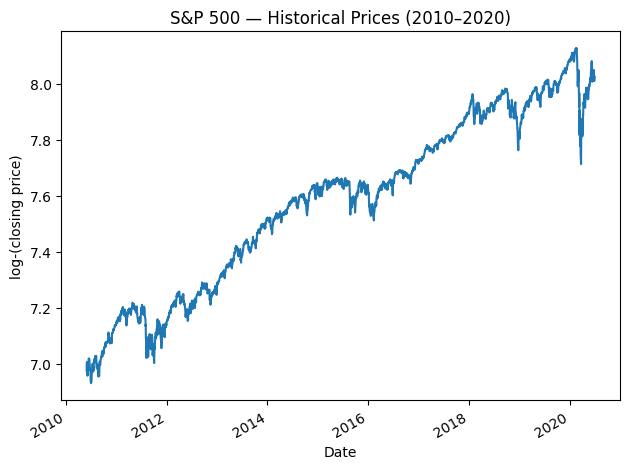

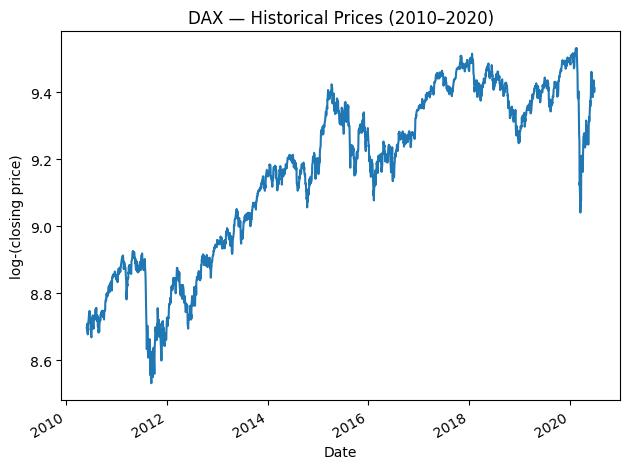

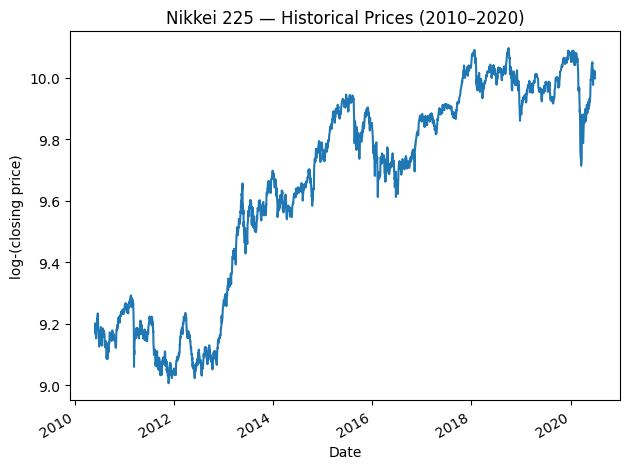

In [8]:
# We take the log of the prices, since when differentiated, they approximate the returns
sp500 = np.log(np.maximum(reading_file("sp500_data.csv").astype(float), 1e-8)) 
dax = np.log(np.maximum(reading_file("dax_data.csv").astype(float), 1e-8))         
nikkei = np.log(np.maximum(reading_file("nikkei_data.csv").astype(float), 1e-8))    

# Plot each index
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    df["Close"].plot(title=f"{name} — Historical Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("log-(closing price)")
    plt.tight_layout()
    plt.show()


In the following, we analyze the **stationarity** of the time series by applying **unit root tests** such as *ADF* and *KPSS*.


In [9]:
results = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close"])
    results.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table = pd.DataFrame(results, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table.style.set_properties(**{'white-space': 'pre-wrap'}))

,ADF,KPSS
Stock index,,
S&P 500,-1.25 (0.65),122.17 (0.01)
DAX,-1.76 (0.40),110.00 (0.01)
Nikkei 225,-1.19 (0.68),108.86 (0.01)


## Stationarity test (ADF)

We use the **Augmented Dickey–Fuller (ADF)** test, a unit-root test that extends the
classical **Dickey–Fuller (DF)** framework. The DF test is derived under an AR(p)
data-generating process and tests whether the autoregressive root equals one.  
The **ADF** augments the DF regression with **lagged first differences**.

### Specification used in this notebook
With `regression='c'` (intercept only), `maxlag = 1`, and automatic lag selection
(`autolag`), the estimated regression is

$\Delta y_t \;=\; \alpha \;+\; \beta\,y_{t-1} \;+\; \gamma_1\,\Delta y_{t-1} \;+\; Z_t,$

where $\alpha$ is a drift term, $\beta$ is the coefficient associated with the
(unit-root) level term, $\gamma_1$ controls short-run dynamics, and
$Z_t$ is white noise.

- **Null hypothesis** $H_0:\ \beta = 0$  
  (equivalently, the AR root is 1 ⇒ the series has a **unit root** ⇒ **non-stationary**).
- **Alternative** $H_1:\ \beta < 0$  
(the series is **stationary** around a constant).

> With `maxlag = 1`, `autolag` effectively chooses to include  1 lag
> of $\Delta y$; the selected specification is the one reported above.

### Interpreting the p-value
- **Small p-value** (e.g., ≤ 0.05): reject \(H_0\) ⇒ evidence **against** a unit root
  (stationarity under the chosen deterministic terms).
- **Large p-value**: do **not** reject \(H_0\) ⇒ results consistent with a unit root
  (non-stationarity).

# Differentiating the time series

In what follows we apply **integer** and **fractional** differencing to obtain
(time-)**stationary** series better suited for forecasting.

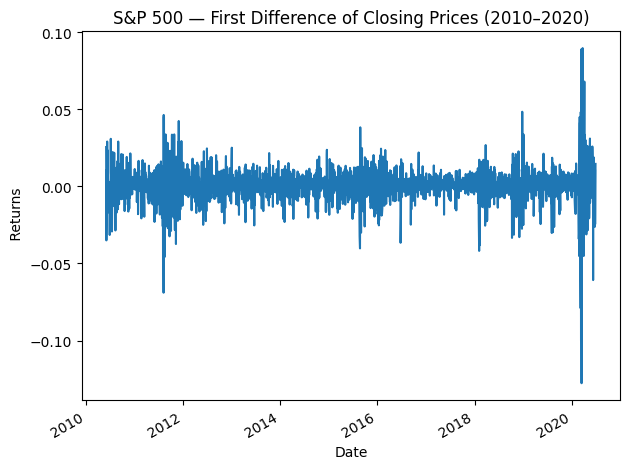

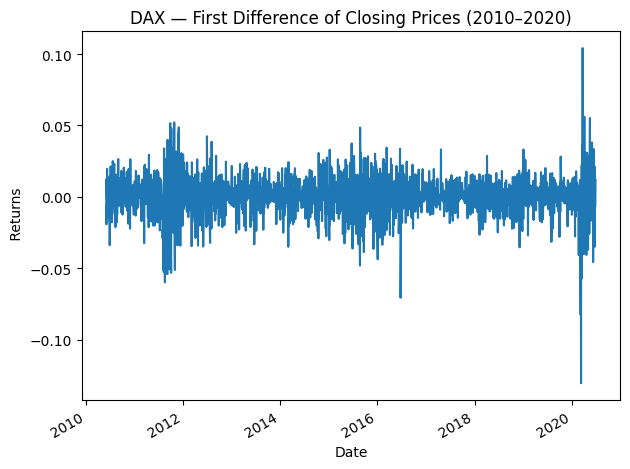

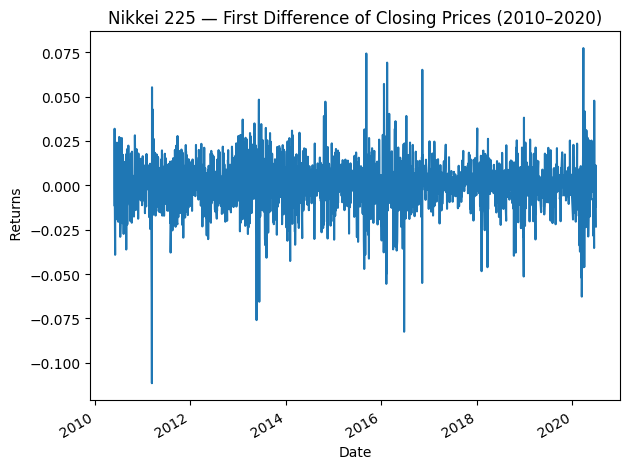

In [10]:
# Integer differencing (d = 1) 
# We can also think at the integer differeciated series as the returns series

base_cols = ['Open','High','Low','Close']

for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # Add first difference columns to the dataframe
    df = add_frac_diff_column(df, order_diff=1, cols=base_cols, mode="integer")
    df["Close_d"].plot(title=f"{name} — First Difference of Closing Prices (2010–2020)")
    plt.xlabel("Date")
	# Return since we are differentiating the log-prices
    plt.ylabel(" Returns")
    plt.tight_layout()
    plt.show()

In [11]:
# ADF and KPSS on the differenced series (quick check) 
results_diff = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_d"])
    results_diff.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_diff = pd.DataFrame(results_diff, columns=["Stock index", "ADF ", "KPSS "]).set_index("Stock index")
display(table_diff.style.set_properties(**{'white-space': 'pre-wrap'}))

,ADF,KPSS
Stock index,,
S&P 500,-35.15 (0.00),0.04 (0.10)
DAX,-34.88 (0.00),0.05 (0.10)
Nikkei 225,-34.25 (0.00),0.06 (0.10)


As expected, the **first difference** (d = 1) yields (near-)stationary series. The ADF statistic typically moves from around **−1/−2** to **−20/−30**, indicating strong evidence against a unit root. This suggests that a **fractional** order might suffice to reach stationarity while **preserving more memory** than d = 1.


# Fractional Differentiation

We now apply **fractional differencing** to the closing prices.  
Our goal is to obtain (near-)stationarity while retaining as much memory of the original series as possible.  


## Finding the best order of differentiation

We now test a range of fractional orders $ d \in \{0.1, 0.2, \ldots, 0.9\} $ to identify the smallest value that yields (near-)stationarity for each index. The goal is to analyze how the ADF statistic varies with the order of fractional differencing, in order to identify the optimal degree ( $ d^* $ ) that achieves stationarity.
The ADF test is computed only on the fractional differentiated log-(closing price), which serves as a representative indicator of stationarity.
Once the optimal order ( $ d^* $ ) is determined, the same value is then applied to all features (Open, High, Low, Close) that will be used as inputs to our model.

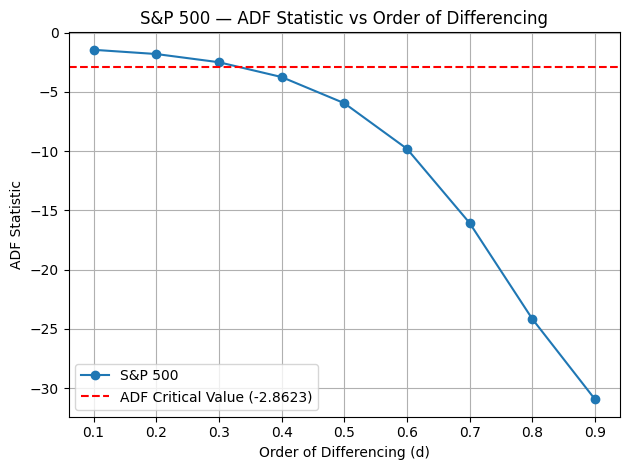

Estimated order of stationarity for S&P 500: ~ 0.329


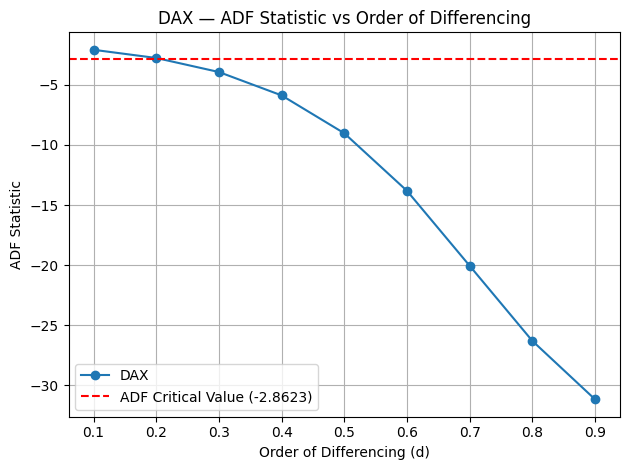

Estimated order of stationarity for DAX: ~ 0.209


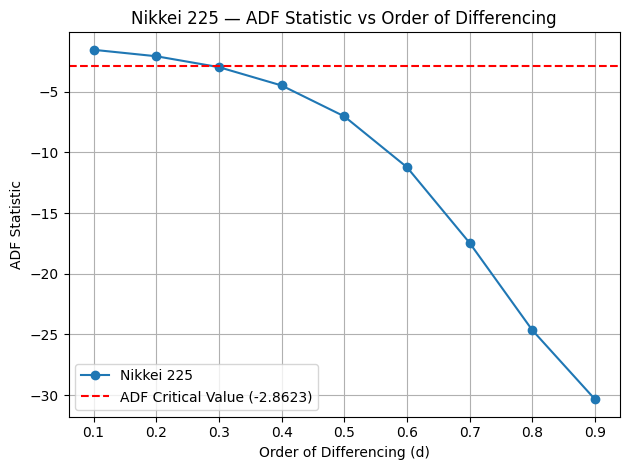

Estimated order of stationarity for Nikkei 225: ~ 0.289


In [12]:
# Plot the ADF results vs order of differentiation
frac_orders = []
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for name, df in {
	"S&P 500": sp500,
	"DAX": dax,
	"Nikkei 225": nikkei,
}.items():
	cval = -2.8623  # ADF critical value at 5% for n > 1000
	rows = sweep_fractional_orders(df, d_grid)
	d_values = [r['d'] for r in rows]
	adf_stats = [r['adf_stat'] for r in rows]
	plt.title(f"{name} — ADF Statistic vs Order of Differencing")
	plt.plot(d_values, adf_stats, marker='o', label=name)
	plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
	plt.xlabel("Order of Differencing (d)")
	plt.ylabel("ADF Statistic")
	plt.legend()
	plt.grid()
	plt.tight_layout()
	plt.show()
	# Intersection between ADF stats and critical value
	# find first crossing where ADF goes from > cval to <= cval
	d_values  = np.asarray(d_values, dtype=float)
	adf_stats = np.asarray(adf_stats, dtype=float)
	mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
	idx = np.where(mask)[0]
	i = idx[0]
	# linear interpolation
	d1, d2 = d_values[i], d_values[i+1]
	a1, a2 = adf_stats[i], adf_stats[i+1]
	d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
	print(f"Estimated order of stationarity for {name}: ~ {d_star:.3f}")
	frac_orders.append((name, d_star))

In [13]:
# Given fractional orders 
frac_orders = dict(frac_orders)

sp500 = add_frac_diff_column(sp500, order_diff=frac_orders["S&P 500"],  cols=base_cols, mode="fractional")

dax   = add_frac_diff_column(dax,   order_diff=frac_orders["DAX"],    cols=base_cols, mode="fractional")

nikkei = add_frac_diff_column(nikkei, order_diff=frac_orders["Nikkei 225"], cols=base_cols, mode="fractional")

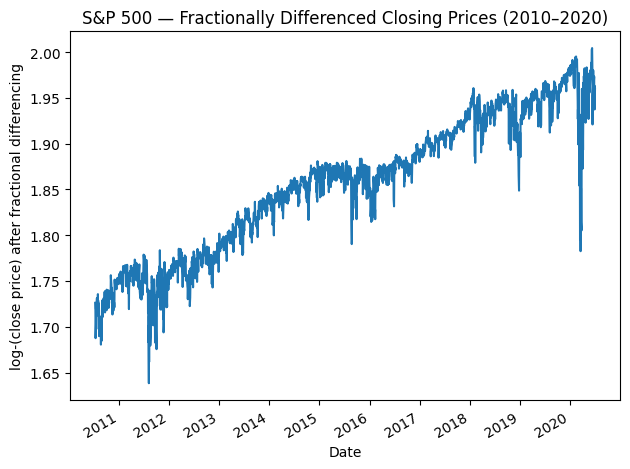

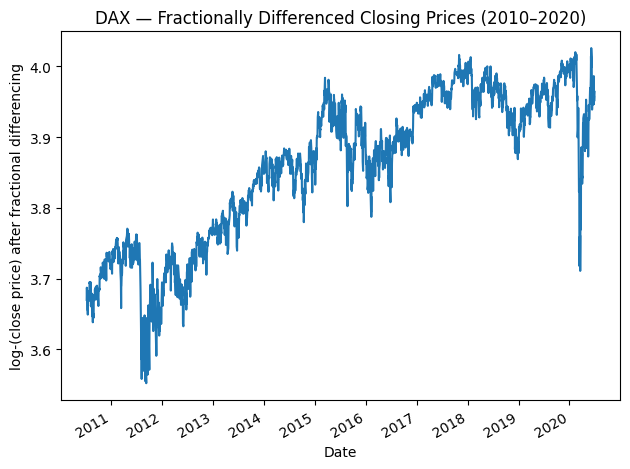

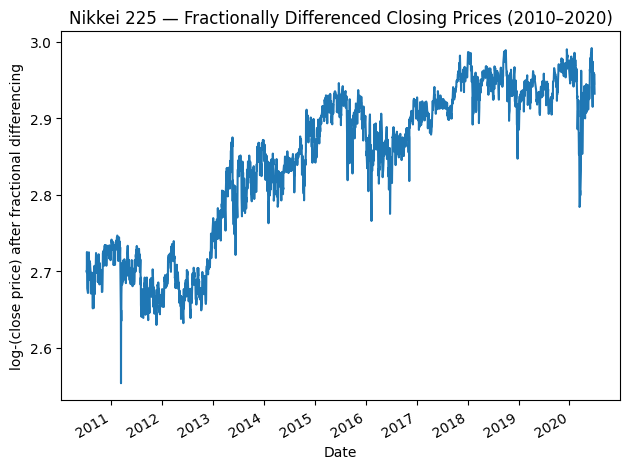

In [14]:
# Plot fractionally differenced series
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # I would suggest to skip first few NaNs due to differencing for better visualization
    df["Close_fd"].plot(title=f"{name} — Fractionally Differenced Closing Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("log-(close price) after fractional differencing")
    plt.tight_layout()
    plt.show()

In [15]:
# Stationarity tests on fractionally differenced series 
results_fd = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_fd"])  
    results_fd.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_fd = pd.DataFrame(results_fd, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table_fd.style.set_properties(**{'white-space': 'pre-wrap'}))

,ADF,KPSS
Stock index,,
S&P 500,-2.79 (0.06),117.33 (0.01)
DAX,-2.84 (0.05),104.55 (0.01)
Nikkei 225,-2.84 (0.05),103.37 (0.01)


### Original vs Fractional differentiated plot

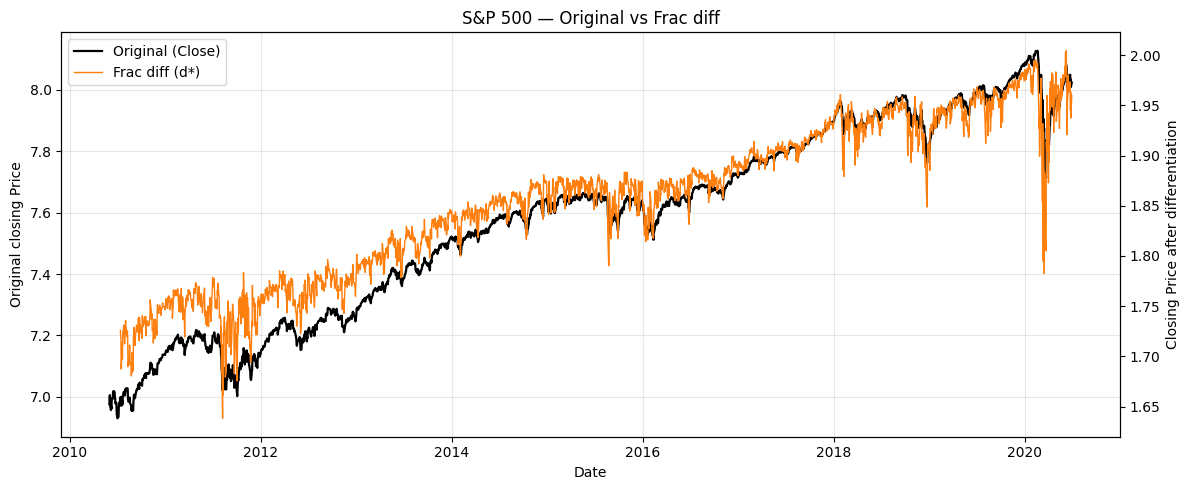

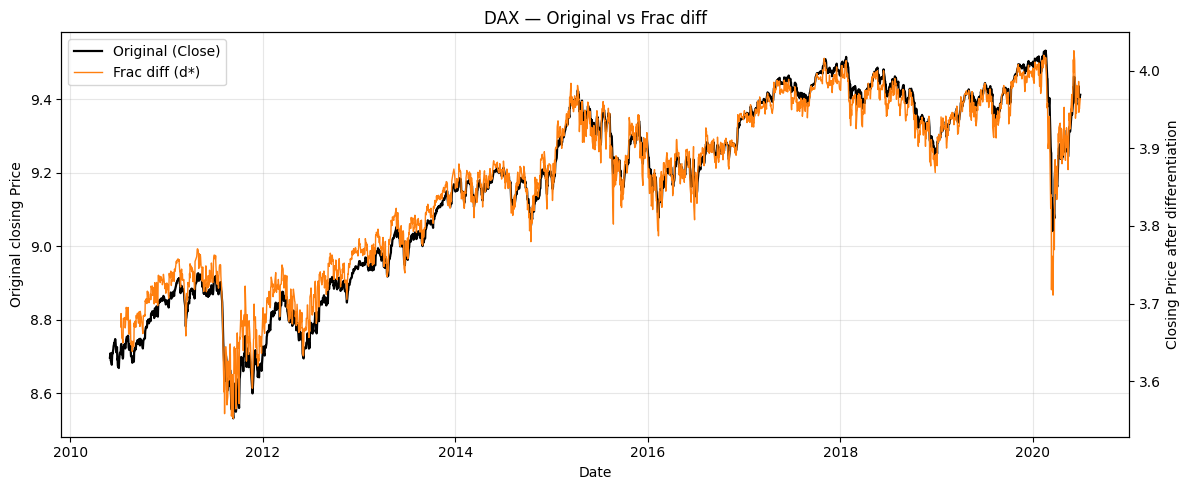

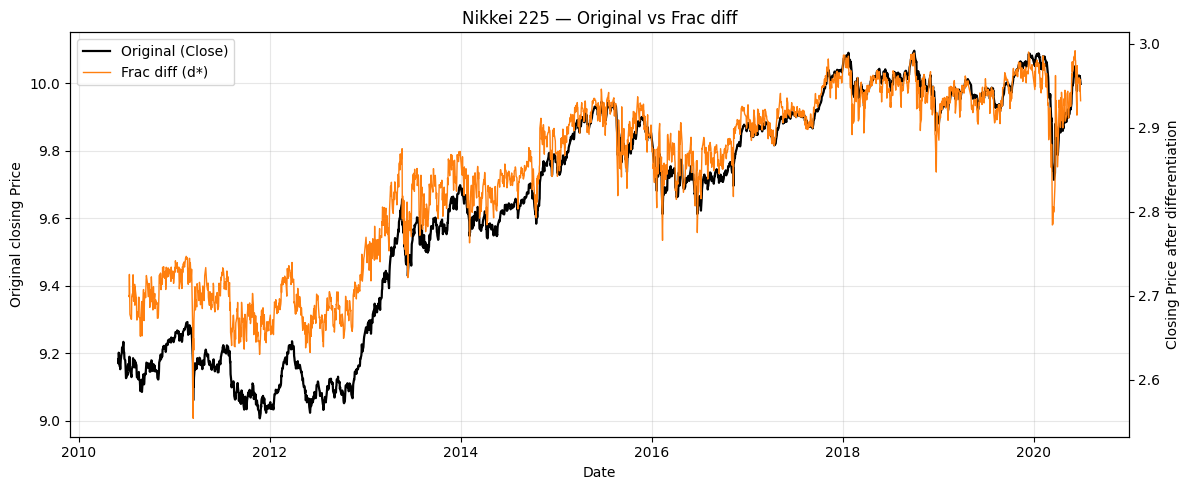

In [16]:
# Combined visualization: original vs diff vs frac diff 
plot_close_diff_frac_one("S&P 500 — Original vs Frac diff", sp500)
plot_close_diff_frac_one("DAX — Original vs Frac diff", dax)
plot_close_diff_frac_one("Nikkei 225 — Original vs Frac diff", nikkei)

# Forecasting 

In what follows, we are going to use linear regression and a shallow neural network to predict the return of the next-day. In particular we are also going to compare two different approaches: 
- one-step ahead, we want to predict the return of the next-day using the Close, Open, Low and High of the day before,
- sliding window, we want to predict the return of the next-day using  Close, Open, Low and High of the 5 day before.
In addition we want to compare how these different approaches and model behave while we use the differentiated time series and the fractional differentiated one.
After forecasting we are going to compare the result using the differnt kind of data using the RMSE (root mean squared error ) and MAE ( mean absolute error) as metrics.
In the end we want to see how the model behave if we use them for trading.

In [17]:
# Prepare dataseta for onest step ahead 

fd_cols   = ['Close_fd','Open_fd','High_fd','Low_fd']
diff_cols = ['Close_d','Open_d','High_d','Low_d']

# S&P 500 — fractional differentiation
train_sp500_fd, val_sp500_fd, test_sp500_fd, target_sp500_fd_tr, target_sp500_fd_val, target_sp500_fd_te = prepare_data(sp500, fd_cols)

# S&P 500 — integer differentation
train_sp500_d,  val_sp500_d,  test_sp500_d,  target_sp500_d_tr,  target_sp500_d_val,  target_sp500_d_te  = prepare_data(sp500, diff_cols)

# DAX — fractional
train_dax_fd, val_dax_fd, test_dax_fd, target_dax_fd_tr, target_dax_fd_val, target_dax_fd_te = prepare_data(dax, fd_cols)

# DAX — integer
train_dax_d,  val_dax_d,  test_dax_d,  target_dax_d_tr,  target_dax_d_val,  target_dax_d_te  = prepare_data(dax, diff_cols)

# Nikkei — fractional
train_nikkei_fd, val_nikkei_fd, test_nikkei_fd, target_nikkei_fd_tr, target_nikkei_fd_val, target_nikkei_fd_te = prepare_data(nikkei, fd_cols)

# Nikkei — integer
train_nikkei_d,  val_nikkei_d,  test_nikkei_d,  target_nikkei_d_tr,  target_nikkei_d_val,  target_nikkei_d_te  = prepare_data(nikkei, diff_cols)

In [18]:
# Prepare data using sliding window approach

window_size = 5
# S&P 500 — fractional 
train_sp500_fd_sw, val_sp500_fd_sw, test_sp500_fd_sw, target_sp500_fd_tr_sw, target_sp500_fd_val_sw, target_sp500_fd_te_sw = prepare_data_sw(sp500, fd_cols, window_size)	

# S&P 500 — integer 
train_sp500_d_sw, val_sp500_d_sw,  test_sp500_d_sw,  target_sp500_d_tr_sw,  target_sp500_d_val_sw,  target_sp500_d_te_sw  = prepare_data_sw(sp500, diff_cols, window_size)

# DAX — fractional 
train_dax_fd_sw, val_dax_fd_sw, test_dax_fd_sw, target_dax_fd_tr_sw, target_dax_fd_val_sw, target_dax_fd_te_sw = prepare_data_sw(dax, fd_cols, window_size)

# DAX — integer
train_dax_d_sw, val_dax_d_sw,  test_dax_d_sw,  target_dax_d_tr_sw,  target_dax_d_val_sw,  target_dax_d_te_sw  = prepare_data_sw(dax, diff_cols, window_size)

# Nikkei — fractional
train_nikkei_fd_sw, val_nikkei_fd_sw, test_nikkei_fd_sw, target_nikkei_fd_tr_sw, target_nikkei_fd_val_sw, target_nikkei_fd_te_sw = prepare_data_sw(nikkei, fd_cols, window_size)

# Nikkei — integer
train_nikkei_d_sw, val_nikkei_d_sw,  test_nikkei_d_sw,  target_nikkei_d_tr_sw,  target_nikkei_d_val_sw,  target_nikkei_d_te_sw  = prepare_data_sw(nikkei, diff_cols, window_size)

## Linear regression 
In the last part of this notebook we want to understand better how much does the fractional differentiation of the data helps us, indeed we try to do the one-step-ahead prediction and the sliding window one, using a simple linear regression.

## Linear regression one-step-ahead

In [19]:
# Linear regression one-step-ahead forecasting
results_l = {}
results_l["sp500_fd"]  = lin_reg('lin_reg_sp500_fd.pkl', train_sp500_fd, np.vstack((val_sp500_fd,test_sp500_fd)), target_sp500_fd_tr, np.vstack((target_sp500_fd_val,target_sp500_fd_te)) )
results_l["sp500_d"]   = lin_reg('lin_reg_sp500_d.pkl', train_sp500_d, np.vstack((val_sp500_d, test_sp500_d)),  target_sp500_d_tr,  np.vstack((target_sp500_d_val, target_sp500_d_te)) )

results_l["dax_fd"]    = lin_reg( 'lin_reg_dax_fd.pkl', train_dax_fd, np.vstack((val_dax_fd, test_dax_fd)), target_dax_fd_tr, np.vstack((target_dax_fd_val, target_dax_fd_te)) )
results_l["dax_d"]     = lin_reg( 'lin_reg_dax_d.pkl', train_dax_d, np.vstack((val_dax_d, test_dax_d)), target_dax_d_tr, np.vstack((target_dax_d_val, target_dax_d_te)) )

results_l["nikkei_fd"] = lin_reg( 'lin_reg_nikkei_fd.pkl', train_nikkei_fd, np.vstack((val_nikkei_fd, test_nikkei_fd)), target_nikkei_fd_tr, np.vstack((target_nikkei_fd_val, target_nikkei_fd_te)) )
results_l["nikkei_d"]  = lin_reg( 'lin_reg_nikkei_d.pkl', train_nikkei_d, np.vstack((val_nikkei_d, test_nikkei_d)), target_nikkei_d_tr, np.vstack((target_nikkei_d_val, target_nikkei_d_te)) )

# Print results
for k, v in results_l.items():
    rmse, mae = v
    print(f"{k:10s} -> RMSE={rmse:.6f} | MAE={mae:.6f}")

sp500_fd   -> RMSE=0.014061 | MAE=0.008021
sp500_d    -> RMSE=0.013997 | MAE=0.007881
dax_fd     -> RMSE=0.013464 | MAE=0.008493
dax_d      -> RMSE=0.013422 | MAE=0.008441
nikkei_fd  -> RMSE=0.012476 | MAE=0.008395
nikkei_d   -> RMSE=0.012405 | MAE=0.008294


In [20]:
# Compare differetiated data vs fractionally differetiated data
for m in ["rmse","mae"]:
    df, avg = compare_models(results_l, metric=m, mode='no loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")


RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.013997         0.014061        -0.000064        -0.457381
   DAX      0.013422         0.013464        -0.000041        -0.309143
NIKKEI      0.012405         0.012476        -0.000071        -0.571855
AVERAGE  Δ=-0.000059   Δ%=-0.45% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.007881        0.008021        -0.000139        -1.766997
   DAX     0.008441        0.008493        -0.000052        -0.617149
NIKKEI     0.008294        0.008395        -0.000101        -1.214647
AVERAGE  Δ=-0.000097   Δ%=-1.20% 


## Linear Regression with sliding window

In [21]:
# Linear regression with sliding window approach
results_l_sw = {}
results_l_sw["sp500_fd"] = lin_reg( 'lin_reg_sp500_fd_sw.pkl', train_sp500_fd_sw, np.vstack((val_sp500_fd_sw,test_sp500_fd_sw)), target_sp500_fd_tr_sw, np.vstack((target_sp500_fd_val_sw,target_sp500_fd_te_sw)))
results_l_sw["sp500_d"]  = lin_reg( 'lin_reg_sp500_d_sw.pkl', train_sp500_d_sw, np.vstack((val_sp500_d_sw, test_sp500_d_sw)),  target_sp500_d_tr_sw,  np.vstack((target_sp500_d_val_sw, target_sp500_d_te_sw)) )

results_l_sw["dax_fd"]   = lin_reg( 'lin_reg_dax_fd_sw.pkl', train_dax_fd_sw, np.vstack((val_dax_fd_sw, test_dax_fd_sw)), target_dax_fd_tr_sw, np.vstack((target_dax_fd_val_sw, target_dax_fd_te_sw)) )
results_l_sw["dax_d"]    = lin_reg( 'lin_reg_dax_d_sw.pkl', train_dax_d_sw, np.vstack((val_dax_d_sw, test_dax_d_sw)), target_dax_d_tr_sw, np.vstack((target_dax_d_val_sw, target_dax_d_te_sw)) )

results_l_sw["nikkei_fd"] = lin_reg( 'lin_reg_nikkei_fd_sw.pkl', train_nikkei_fd_sw, np.vstack((val_nikkei_fd_sw, test_nikkei_fd_sw)), target_nikkei_fd_tr_sw, np.vstack((target_nikkei_fd_val_sw, target_nikkei_fd_te_sw)) )
results_l_sw["nikkei_d"]  = lin_reg( 'lin_reg_nikkei_d_sw.pkl', train_nikkei_d_sw, np.vstack((val_nikkei_d_sw, test_nikkei_d_sw)), target_nikkei_d_tr_sw, np.vstack((target_nikkei_d_val_sw, target_nikkei_d_te_sw)) )

# Print results
for k, v in results_l_sw.items():
    rmse, mae = v
    print(f"{k:10s} -> RMSE={rmse:.6f} | MAE={mae:.6f}")

sp500_fd   -> RMSE=0.014346 | MAE=0.008084
sp500_d    -> RMSE=0.014356 | MAE=0.008023
dax_fd     -> RMSE=0.013837 | MAE=0.008564
dax_d      -> RMSE=0.013969 | MAE=0.008567
nikkei_fd  -> RMSE=0.012629 | MAE=0.008557
nikkei_d   -> RMSE=0.012610 | MAE=0.008454


In [22]:
# Compare differetiated data vs fractionally differetiated data
for m in ["rmse","mae"]:
    df, avg = compare_models(results_l_sw, metric=m, mode='no loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")


RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.014356         0.014346         0.000009         0.064867
   DAX      0.013969         0.013837         0.000133         0.950059
NIKKEI      0.012610         0.012629        -0.000019        -0.149624
AVERAGE  Δ=0.000041   Δ%=0.29% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.008023        0.008084        -0.000061        -0.762375
   DAX     0.008567        0.008564         0.000002         0.028372
NIKKEI     0.008454        0.008557        -0.000103        -1.216942
AVERAGE  Δ=-0.000054   Δ%=-0.65% 


## ANN one-step-ahead

In what follows, we specify a shallow feed-forward neural network (one hidden layer) that takes the daily OHLC (Open, High, Low, Close) values of each index (already differentiaed and therefore stationary) as inputs and predicts the next-day closing price. The closing price of the next day has been taken as target.
This is a one-step-ahead forecasting setup. The rationale is that fractional differencing preserves long-memory features while improving stationarity, so past information is effectively embedded in the current inputs, making a one-step model appropriate.

100%|██████████| 250/250 [00:04<00:00, 61.42it/s, lr=4.88e-6, train=8.24e-5, val=8.4e-5]  


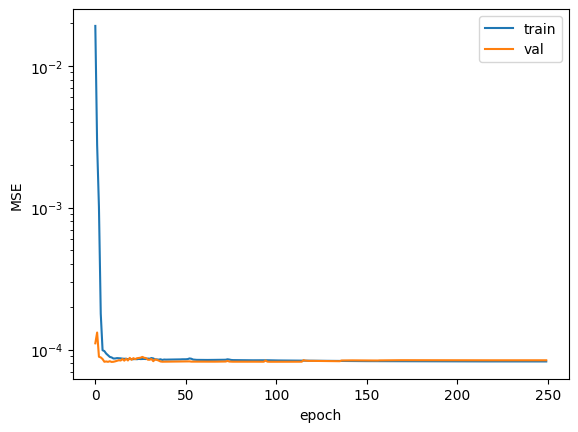

100%|██████████| 250/250 [00:04<00:00, 60.64it/s, lr=4.88e-6, train=5.78e-5, val=0.000131] 


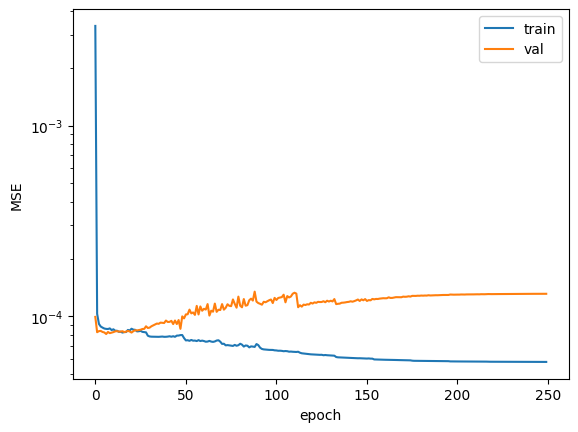

100%|██████████| 250/250 [00:04<00:00, 60.38it/s, lr=4.88e-6, train=0.000156, val=7.65e-5] 


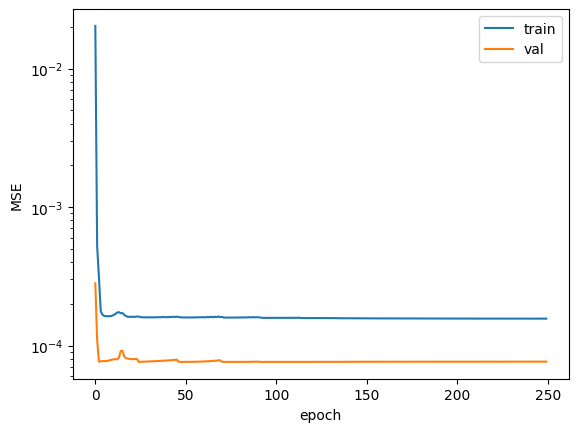

100%|██████████| 250/250 [00:04<00:00, 60.55it/s, lr=4.88e-6, train=0.000114, val=9.53e-5] 


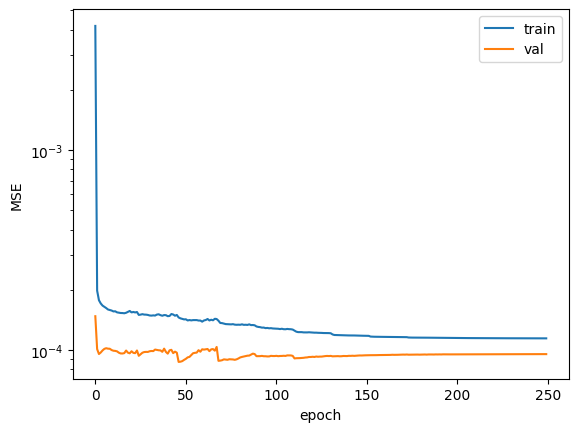

100%|██████████| 250/250 [00:03<00:00, 62.64it/s, lr=4.88e-6, train=0.000178, val=0.000129] 


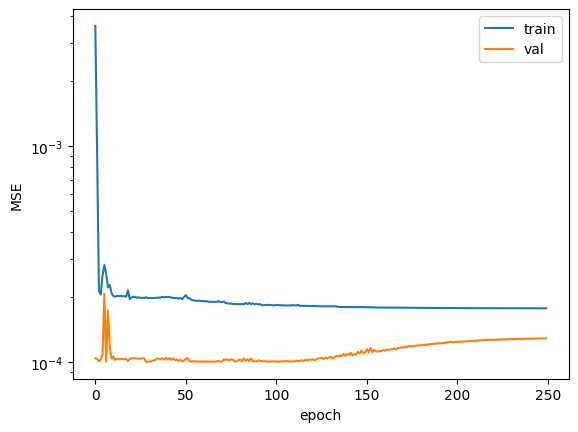

100%|██████████| 250/250 [00:04<00:00, 61.98it/s, lr=4.88e-6, train=0.000141, val=0.000135] 


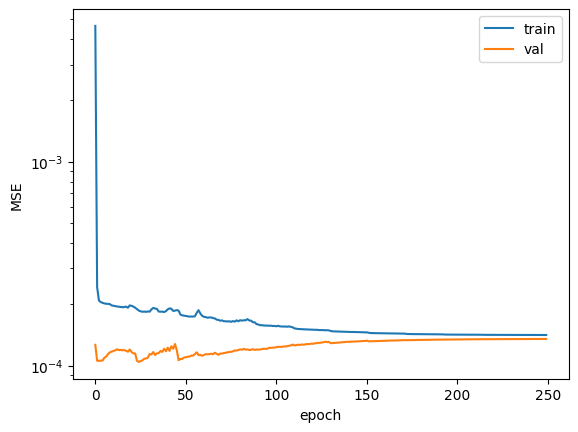

sp500_fd   -> Loss=0.000348 | RMSE=0.018650 | MAE=0.011783 
sp500_d    -> Loss=0.000663 | RMSE=0.025746 | MAE=0.012868 
dax_fd     -> Loss=0.000288 | RMSE=0.016965 | MAE=0.010393 
dax_d      -> Loss=0.000321 | RMSE=0.017917 | MAE=0.011361 
nikkei_fd  -> Loss=0.000241 | RMSE=0.015508 | MAE=0.011183 
nikkei_d   -> Loss=0.000255 | RMSE=0.015957 | MAE=0.010392 


In [23]:
# Train and evaluate
results_os = {}
results_os["sp500_fd"]  = train_evaluate("fd_sp500.weights.pth", train_sp500_fd, val_sp500_fd, test_sp500_fd, target_sp500_fd_tr, target_sp500_fd_val, target_sp500_fd_te, n_features=4)
results_os["sp500_d"]   = train_evaluate("d_sp500.weights.pth", train_sp500_d,  val_sp500_d,  test_sp500_d,  target_sp500_d_tr, target_sp500_d_val, target_sp500_d_te,  n_features=4)

results_os["dax_fd"]    = train_evaluate("fd_dax.weights.pth", train_dax_fd, val_dax_fd, test_dax_fd, target_dax_fd_tr, target_dax_fd_val, target_dax_fd_te, n_features=4)
results_os["dax_d"]     = train_evaluate("d_dax.weights.pth", train_dax_d,  val_dax_d,  test_dax_d,  target_dax_d_tr, target_dax_d_val, target_dax_d_te,  n_features=4)

results_os["nikkei_fd"] = train_evaluate("fd_nikkei.weights.pth", train_nikkei_fd, val_nikkei_fd, test_nikkei_fd, target_nikkei_fd_tr, target_nikkei_fd_val, target_nikkei_fd_te, n_features=4)
results_os["nikkei_d"]  = train_evaluate("d_nikkei.weights.pth", train_nikkei_d,  val_nikkei_d,  test_nikkei_d,  target_nikkei_d_tr, target_nikkei_d_val, target_nikkei_d_te,  n_features=4)

# Print results
for k, v in results_os.items():
    loss, rmse, mae = v
    print(f"{k:10s} -> Loss={loss:.6f} | RMSE={rmse:.6f} | MAE={mae:.6f} ")

In [24]:
# Improvement of using fractional differetiation instead of integer differentiation
for m in ["loss","rmse","mae"]:
    df, avg = compare_models(results_os, metric=m, mode='loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")



LOSS
 index  loss_integer  loss_fractional  abs_improvement  pct_improvement
 SP500      0.000663         0.000348         0.000315        47.526931
   DAX      0.000321         0.000288         0.000033        10.346898
NIKKEI      0.000255         0.000241         0.000014         5.548556
AVERAGE  Δ=0.000121   Δ%=21.14% 

RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.025746         0.018650         0.007096        27.561703
   DAX      0.017917         0.016965         0.000952         5.314678
NIKKEI      0.015957         0.015508         0.000449         2.813867
AVERAGE  Δ=0.002832   Δ%=11.90% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.012868        0.011783         0.001085         8.432619
   DAX     0.011361        0.010393         0.000968         8.522101
NIKKEI     0.010392        0.011183        -0.000791        -7.612715
AVERAGE  Δ=0.000421   Δ%=3.11% 


In what follows, we compare differentiated data with fractionally differentiated data using an ANN with a sliding window. Instead of predicting tomorrow's log-closing price based on today's OHLC data, the input dataset consists of a frame of past data. 

The heuristic idea is that if fractional differentiation effectively preserves memory, there should be little difference between using today's features or a frame of past features. 

To further explore this, we also perform the same comparison using simple linear regression.

# ANN with sliding window

100%|██████████| 250/250 [00:02<00:00, 120.81it/s, lr=0.000625, train=7.37e-5, val=9.86e-5] 


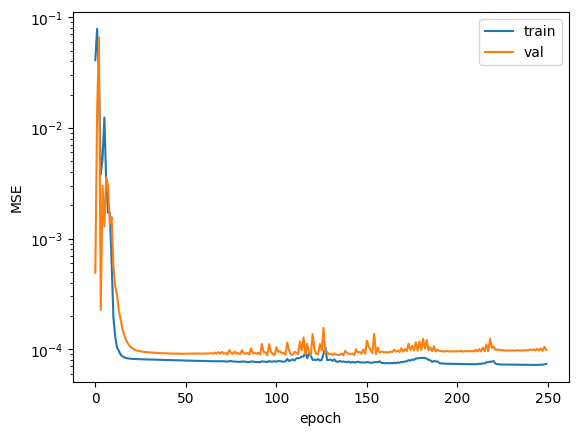

100%|██████████| 250/250 [00:02<00:00, 120.77it/s, lr=0.000156, train=3.6e-5, val=0.000162] 


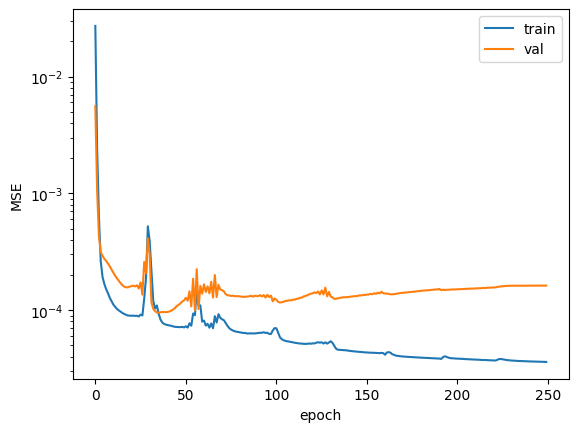

100%|██████████| 250/250 [00:02<00:00, 119.82it/s, lr=0.000156, train=0.000144, val=7.74e-5]


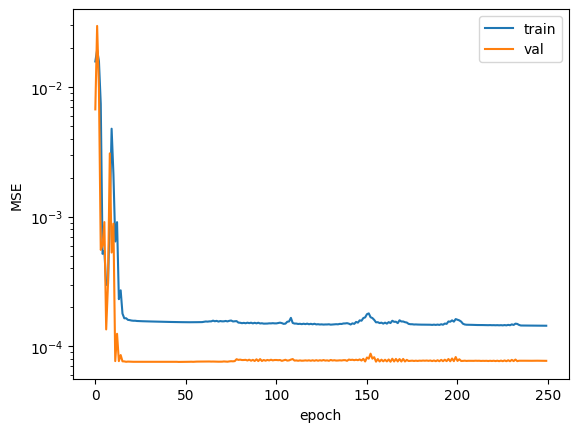

100%|██████████| 250/250 [00:02<00:00, 120.16it/s, lr=0.000313, train=0.00012, val=9.91e-5] 


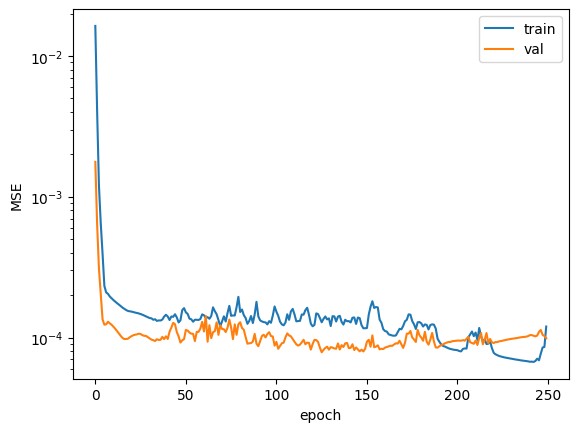

100%|██████████| 250/250 [00:02<00:00, 123.77it/s, lr=7.81e-5, train=0.000174, val=0.000124] 


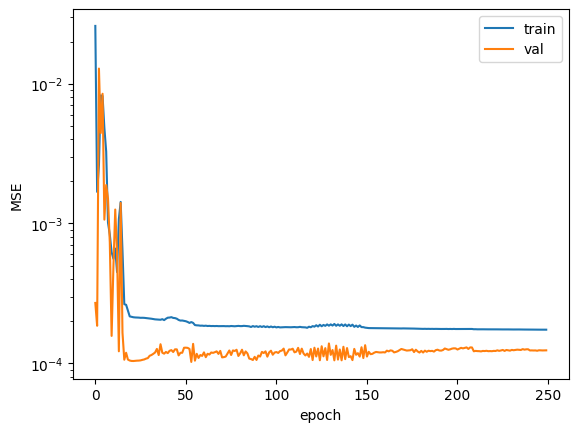

100%|██████████| 250/250 [00:02<00:00, 122.88it/s, lr=7.81e-5, train=6.87e-5, val=0.000196]  


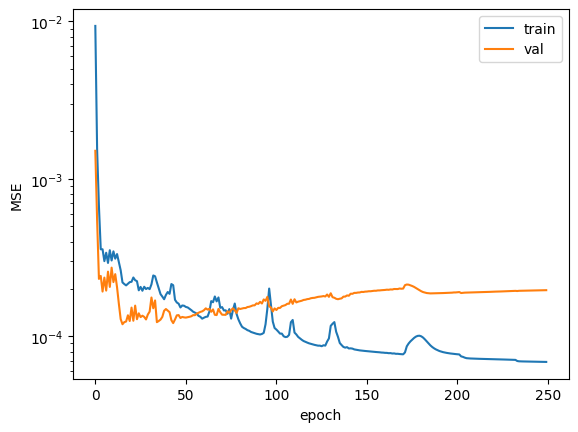

sp500_fd   -> Loss=0.000388 | RMSE=0.019694 | MAE=0.011785 
sp500_d    -> Loss=0.001219 | RMSE=0.034921 | MAE=0.017286 
dax_fd     -> Loss=0.000315 | RMSE=0.017739 | MAE=0.010617 
dax_d      -> Loss=0.000714 | RMSE=0.026713 | MAE=0.014426 
nikkei_fd  -> Loss=0.000231 | RMSE=0.015209 | MAE=0.010646 
nikkei_d   -> Loss=0.000383 | RMSE=0.019568 | MAE=0.012728 


In [25]:
# Train and evaluate 
results_sw = {}
results_sw["sp500_fd"]  = train_evaluate_sw("fd_w_sp500.weights.pth", train_sp500_fd_sw, val_sp500_fd_sw, test_sp500_fd_sw, target_sp500_fd_tr_sw, target_sp500_fd_val_sw, target_sp500_fd_te_sw, n_features = window_size * 4)
results_sw["sp500_d"]   = train_evaluate_sw("d_w_sp500.weights.pth", train_sp500_d_sw,  val_sp500_d_sw,  test_sp500_d_sw,  target_sp500_d_tr_sw,  target_sp500_d_val_sw,  target_sp500_d_te_sw,  n_features = window_size * 4)

results_sw["dax_fd"]    = train_evaluate_sw("fd_w_dax.weights.pth", train_dax_fd_sw, val_dax_fd_sw, test_dax_fd_sw, target_dax_fd_tr_sw, target_dax_fd_val_sw, target_dax_fd_te_sw, n_features = window_size * 4)
results_sw["dax_d"]     = train_evaluate_sw("d_w_dax.weights.pth", train_dax_d_sw,  val_dax_d_sw,  test_dax_d_sw,  target_dax_d_tr_sw,  target_dax_d_val_sw,  target_dax_d_te_sw,  n_features = window_size * 4)

results_sw["nikkei_fd"] = train_evaluate_sw("fd_w_nikkei.weights.pth", train_nikkei_fd_sw, val_nikkei_fd_sw, test_nikkei_fd_sw, target_nikkei_fd_tr_sw, target_nikkei_fd_val_sw, target_nikkei_fd_te_sw, n_features = window_size * 4)
results_sw["nikkei_d"]  = train_evaluate_sw("d_w_nikkei.weights.pth", train_nikkei_d_sw,  val_nikkei_d_sw,  test_nikkei_d_sw,  target_nikkei_d_tr_sw,  target_nikkei_d_val_sw,  target_nikkei_d_te_sw,  n_features = window_size * 4)

# Print results
for k, v in results_sw.items():
    loss, rmse, mae = v
    print(f"{k:10s} -> Loss={loss:.6f} | RMSE={rmse:.6f} | MAE={mae:.6f} ")


In [26]:
# Improvement of using fractional differetiation instead of integer differentiation
for m in ["loss","rmse","mae"]:
    df, avg = compare_models(results_sw, metric=m, mode='loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")



LOSS
 index  loss_integer  loss_fractional  abs_improvement  pct_improvement
 SP500      0.001219         0.000388         0.000832        68.193816
   DAX      0.000714         0.000315         0.000399        55.901877
NIKKEI      0.000383         0.000231         0.000152        39.592456
AVERAGE  Δ=0.000461   Δ%=54.56% 

RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.034921         0.019694         0.015226        43.603029
   DAX      0.026713         0.017739         0.008974        33.593582
NIKKEI      0.019568         0.015209         0.004359        22.277710
AVERAGE  Δ=0.009520   Δ%=33.16% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.017286        0.011785         0.005501        31.823131
   DAX     0.014426        0.010617         0.003809        26.402250
NIKKEI     0.012728        0.010646         0.002083        16.362555
AVERAGE  Δ=0.003797   Δ%=24.86% 


## 💹 Using the trained model as a Trading Signal

We now want to see how the model performs when used for **trading decisions** rather than pure prediction.
In particular, we’ll check whether the **fractionally differenced model** provides a better trading signal than the **integer-differenced** one.

**Trading logic (single-unit strategy):**

* For each day in the **test set**, the model predicts tomorrow’s log-closing price.
* If the **predicted price for tomorrow** is **higher than today’s closing price**, we take a **long position** (buy one unit).
* Otherwise, we take a **short position** (sell one unit).
* The position is closed at the next day’s close, and the process repeats for the entire test period.

**Evaluation setup:**

* We use the usual **chronological split**, where roughly **33% of all days** form the **testing set**.
* This proportional split ensures comparability across markets that may have **different trading calendars**. 🌍


In [27]:
# One-step-ahead trading strategy evaluation
results_strategy = {}
results_strategy["sp500_fd"]  = trading_signal_strategy(sp500, test_sp500_fd,  "fd_sp500.weights.pth",  mode="fractional", n_features=4, model="neural_network")
results_strategy["sp500_d"]   = trading_signal_strategy(sp500, test_sp500_d,   "d_sp500.weights.pth",   mode="integer",    n_features=4, model="neural_network")
results_strategy["sp500_fd_lr"]  = trading_signal_strategy(sp500, test_sp500_fd,  "lin_reg_sp500_fd.pkl",  mode="fractional", n_features=4, model="linear_regression")
results_strategy["sp500_d_lr"]   = trading_signal_strategy(sp500, test_sp500_d,   "lin_reg_sp500_d.pkl",   mode="integer",    n_features=4, model="linear_regression")

results_strategy["dax_fd"]    = trading_signal_strategy(dax,   test_dax_fd,    "fd_dax.weights.pth",    mode="fractional", n_features=4, model="neural_network")
results_strategy["dax_d"]     = trading_signal_strategy(dax,   test_dax_d,     "d_dax.weights.pth",     mode="integer",    n_features=4, model="neural_network")
results_strategy["dax_fd_lr"]    = trading_signal_strategy(dax,   test_dax_fd,    "lin_reg_dax_fd.pkl",    mode="fractional", n_features=4, model="linear_regression")
results_strategy["dax_d_lr"]     = trading_signal_strategy(dax,   test_dax_d,     "lin_reg_dax_d.pkl",     mode="integer",    n_features=4, model="linear_regression")

results_strategy["nikkei_fd"] = trading_signal_strategy(nikkei, test_nikkei_fd, "fd_nikkei.weights.pth", mode="fractional", n_features=4, model="neural_network")
results_strategy["nikkei_d"]  = trading_signal_strategy(nikkei, test_nikkei_d,  "d_nikkei.weights.pth",  mode="integer",    n_features=4, model="neural_network")
results_strategy["nikkei_fd_lr"] = trading_signal_strategy(nikkei, test_nikkei_fd, "lin_reg_nikkei_fd.pkl", mode="fractional", n_features=4, model="linear_regression")
results_strategy["nikkei_d_lr"]  = trading_signal_strategy(nikkei, test_nikkei_d,  "lin_reg_nikkei_d.pkl",  mode="integer",    n_features=4, model="linear_regression")

#Sliding window trading strategy evaluation
results_strategy_sw = {}
results_strategy_sw["sp500_fd"]  = trading_signal_strategy(sp500, test_sp500_fd_sw,  "fd_w_sp500.weights.pth",  mode="sliding_window", n_features=window_size * 4, model="neural_network")
results_strategy_sw["sp500_d"]   = trading_signal_strategy(sp500, test_sp500_d_sw,   "d_w_sp500.weights.pth",   mode="sliding_window",    n_features=window_size * 4, model="neural_network")
results_strategy_sw["sp500_fd_lr"]  = trading_signal_strategy(sp500, test_sp500_fd_sw,  "lin_reg_sp500_fd_sw.pkl",  mode="sliding_window", n_features=window_size * 4, model="linear_regression")
results_strategy_sw["sp500_d_lr"]   = trading_signal_strategy(sp500, test_sp500_d_sw,   "lin_reg_sp500_d_sw.pkl",   mode="sliding_window",    n_features=window_size * 4, model="linear_regression")

results_strategy_sw["dax_fd"]    = trading_signal_strategy(dax,   test_dax_fd_sw,    "fd_w_dax.weights.pth", mode="sliding_window", n_features=window_size * 4, model="neural_network")
results_strategy_sw["dax_d"]     = trading_signal_strategy(dax,   test_dax_d_sw,     "d_w_dax.weights.pth",  mode="sliding_window",    n_features=window_size * 4, model="neural_network")

results_strategy_sw["dax_fd_lr"]    = trading_signal_strategy(dax,   test_dax_fd_sw,    "lin_reg_dax_fd_sw.pkl",  mode="sliding_window", n_features=window_size * 4, model="linear_regression")
results_strategy_sw["dax_d_lr"]     = trading_signal_strategy(dax,   test_dax_d_sw,     "lin_reg_dax_d_sw.pkl",  mode="sliding_window",    n_features=window_size * 4, model="linear_regression")

results_strategy_sw["nikkei_fd"] = trading_signal_strategy(nikkei, test_nikkei_fd_sw, "fd_w_nikkei.weights.pth",mode="sliding_window", n_features=window_size * 4, model="neural_network")
results_strategy_sw["nikkei_d"]  = trading_signal_strategy(nikkei, test_nikkei_d_sw,  "d_w_nikkei.weights.pth", mode="sliding_window",    n_features=window_size * 4, model="neural_network")
results_strategy_sw["nikkei_fd_lr"] = trading_signal_strategy(nikkei, test_nikkei_fd_sw, "lin_reg_nikkei_fd_sw.pkl", mode="sliding_window", n_features=window_size * 4, model="linear_regression")
results_strategy_sw["nikkei_d_lr"]  = trading_signal_strategy(nikkei, test_nikkei_d_sw,  "lin_reg_nikkei_d_sw.pkl", mode="sliding_window",  n_features=window_size * 4, model="linear_regression")

best_one_step   = best_pnl_per_series(results_strategy)
best_sliding_sw = best_pnl_per_series(results_strategy_sw)


print(" Best total PnL per series (One-Step-Ahead) ")
for s, info in best_one_step.items():
    print(f"{s.upper():7s} | Model: {info['key']:25s} | Total PnL: {info['pnl']:.6f}")

print("\n Best total PnL per series (Sliding Window) ")
for s, info in best_sliding_sw.items():
    print(f"{s.upper():7s} | Model: {info['key']:25s} | Total PnL: {info['pnl']:.6f}")


 Best total PnL per series (One-Step-Ahead) 
SP500   | Model: sp500_d_lr                | Total PnL: 0.776527
DAX     | Model: dax_d                     | Total PnL: 0.373642
NIKKEI  | Model: nikkei_d                  | Total PnL: 0.299182

 Best total PnL per series (Sliding Window) 
SP500   | Model: sp500_fd_lr               | Total PnL: 0.020647
DAX     | Model: dax_fd                    | Total PnL: 0.353893
NIKKEI  | Model: nikkei_fd_lr              | Total PnL: 0.059751
